# **Series temporales Basicas**

In [1]:
print('hola mundo')

hola mundo


In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import welch, find_peaks
from scipy.signal import butter, filtfilt
from scipy.stats import norm
from scipy.fft import fft
import scipy.signal as sig
import numpy as np
import warnings
warnings.filterwarnings('ignore')

Un sistema con:

📈 Trend
* Bollinger Bands
* Moving averages

⚡ Momentum
* RSI
* MACD

📊 Volatilidad
* STD returns
* Bollinger width

💰 Performance
* Cumulative returns

📉 Señales visuales
* BUY / SELL (sin trading real)

In [3]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    return df

def compute_rsi(data, window=14):
    delta = data.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    hist = macd - signal_line

    return macd, signal_line, hist

In [ ]:
df=stock_finance(ticker='NVDA',periodo='2y')
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df)
df["RSI"] = compute_rsi(df["Close"], 14)
df["Buy_Signal"] = (df["RSI"] < 30) & (df["Close"] < df["BB_Lower"])
df["Sell_Signal"] = (df["RSI"] > 70) & (df["Close"] > df["BB_Upper"])

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns,MA_10,MA_20,MA_50,MA_100,...,BB_Middle,BB_Std,BB_Upper,BB_Lower,MACD,MACD_Signal,MACD_Hist,RSI,Buy_Signal,Sell_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2024-06-06,120.788979,125.370048,118.115603,123.833705,664696000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,False,False
2024-06-07,120.679176,121.481788,117.818130,119.563104,412386000,-0.000909,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.008759,-0.001752,-0.007007,NaN,False,False
2024-06-10,121.579597,122.887332,116.807857,120.162052,313434100,0.007461,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.056307,0.009860,0.046447,NaN,False,False
2024-06-11,120.711060,122.667834,118.544624,121.569638,222551200,-0.007144,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.037357,0.015359,0.021998,NaN,False,False
2024-06-12,124.993980,126.671216,122.368311,122.857502,299595000,0.035481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.363743,0.085036,0.278707,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.608217,215.448894,215.478858,212850700,0.062612,217.591402,216.501171,200.031665,192.368181,...,216.501171,9.196036,234.893243,198.109099,4.199347,5.613724,-1.414377,53.896107,False,False
2026-06-02,222.560608,232.009586,221.092318,226.915518,193362900,-0.006864,217.641342,217.716755,201.032899,192.704991,...,217.716755,8.210373,234.137500,201.296010,4.338191,5.358618,-1.020426,51.610359,False,False
2026-06-03,214.500000,222.560613,214.260274,221.461887,160907000,-0.036218,217.056024,218.628193,201.814188,193.001845,...,218.628193,6.547869,231.723931,205.532455,3.754523,5.037799,-1.283276,41.651592,False,False


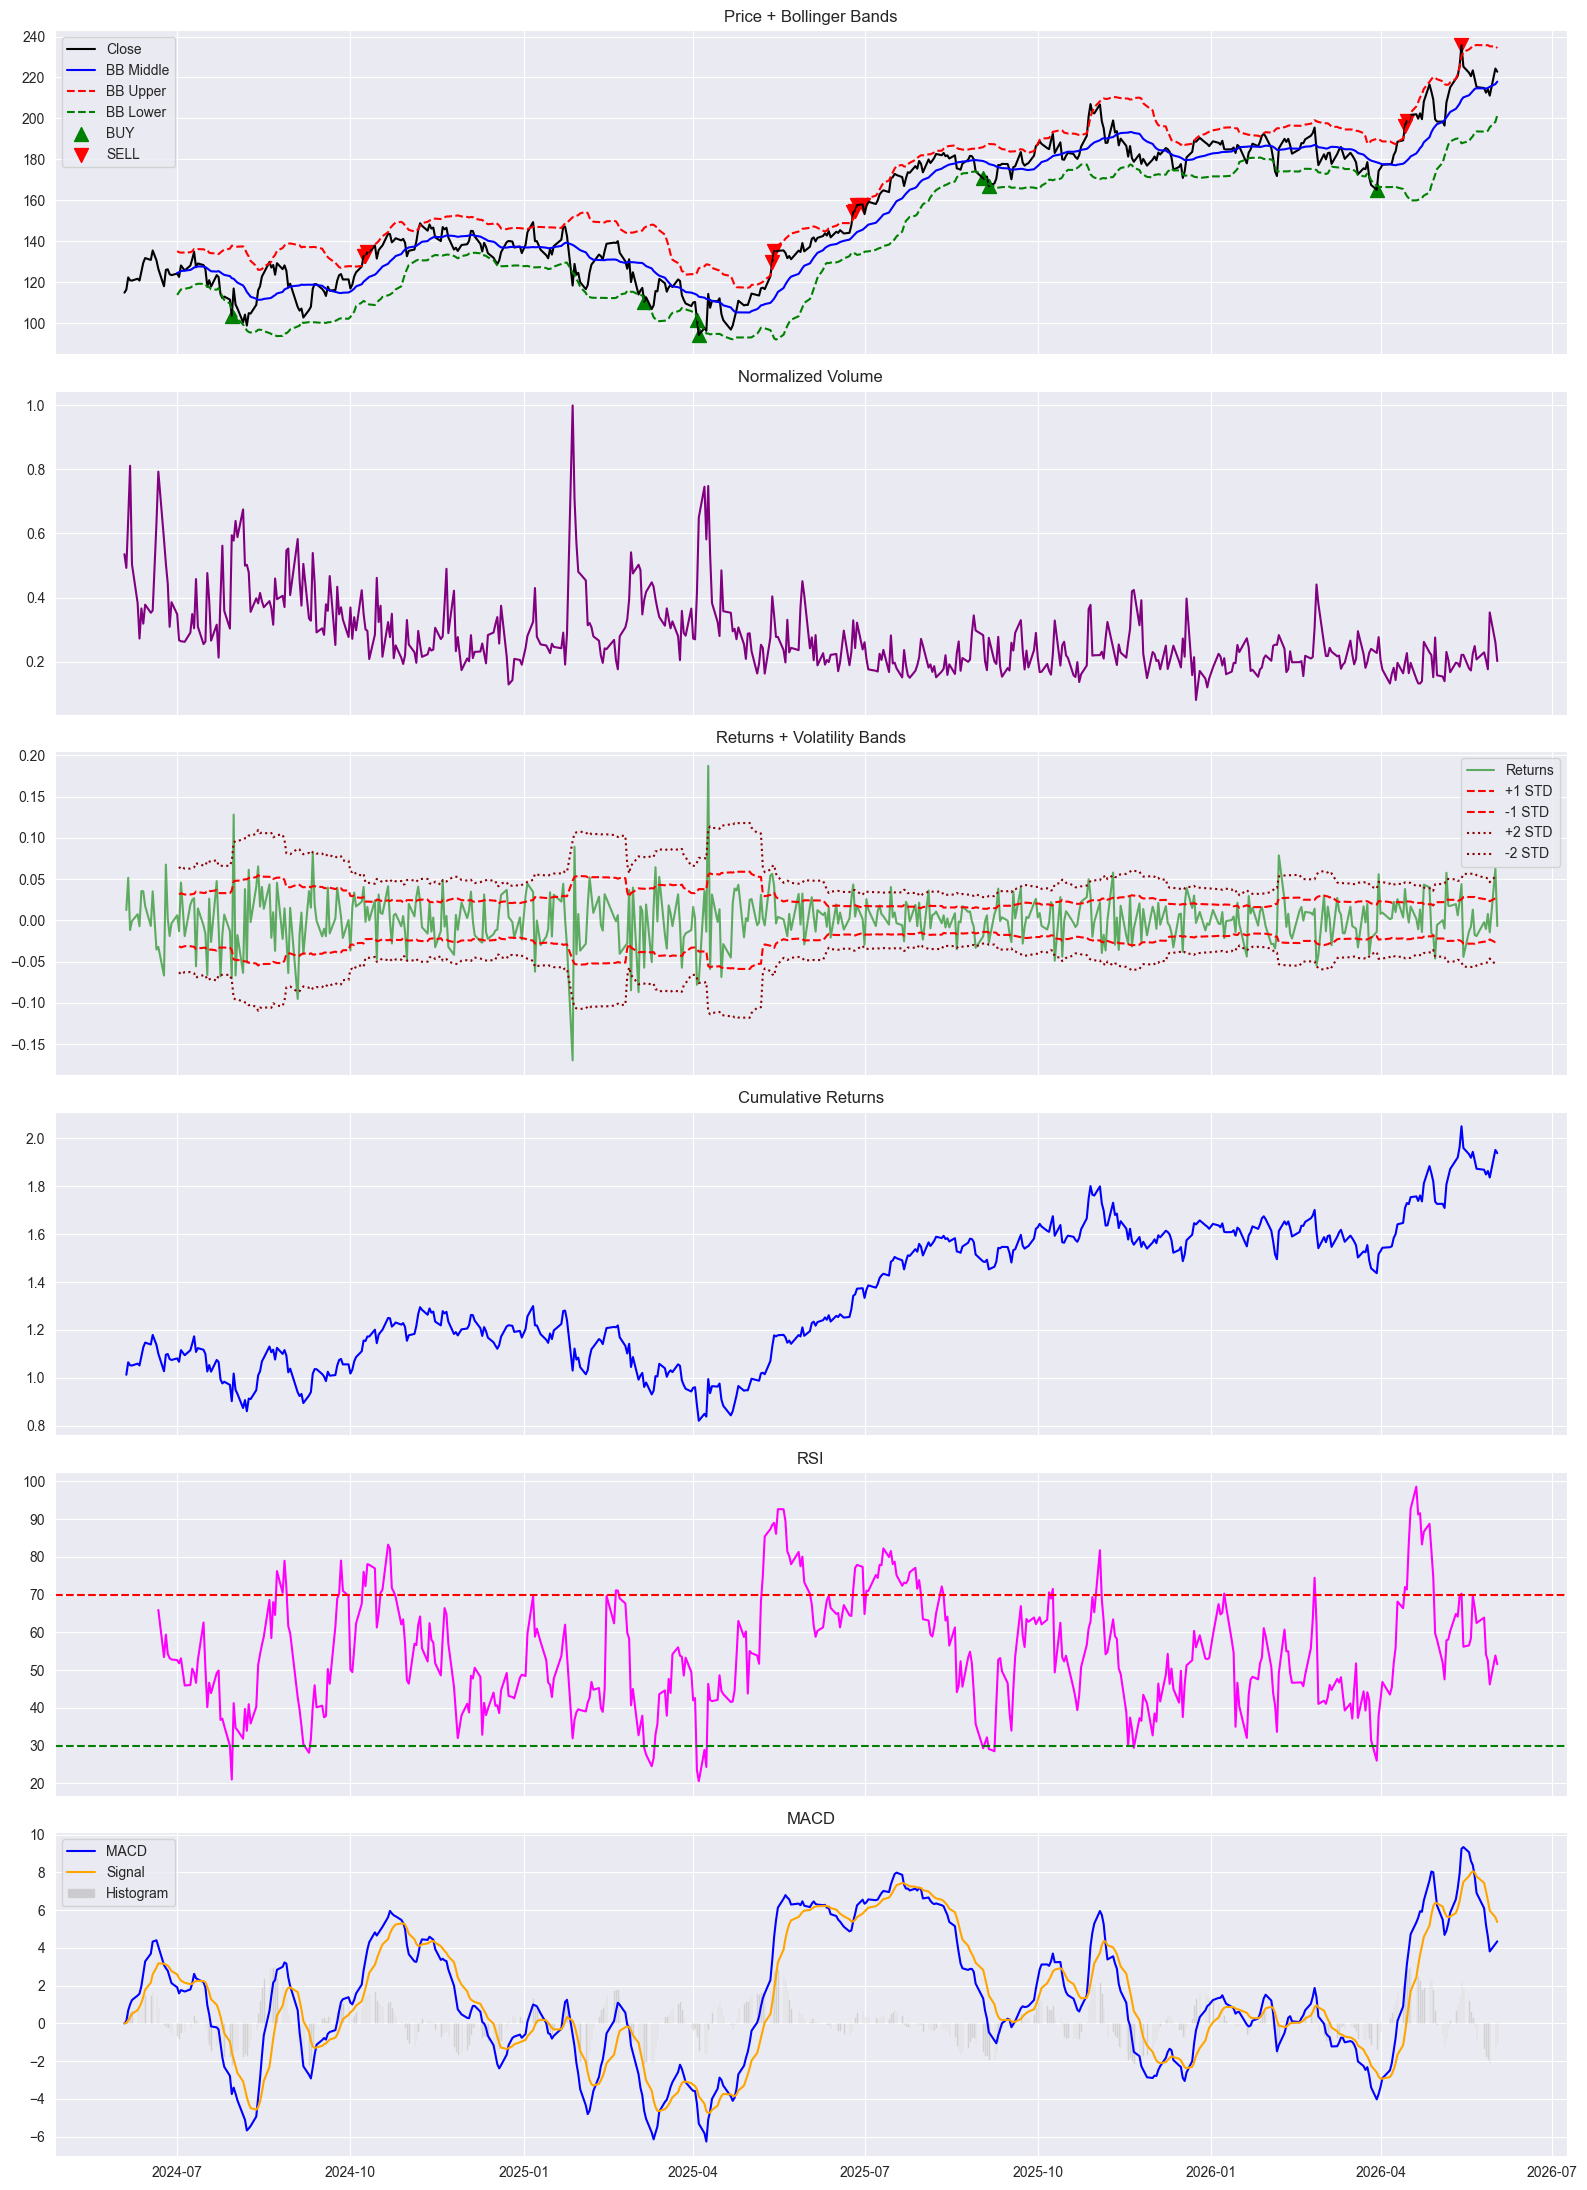

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(6, 1, figsize=(16, 22), sharex=True)

# =========================
# 1. PRICE + BOLLINGER
# =========================
buy = df[df["Buy_Signal"]]
sell = df[df["Sell_Signal"]]
axes[0].plot(df.index, df["Close"], color="black", label="Close")
axes[0].plot(df.index, df["BB_Middle"], color="blue", label="BB Middle")
axes[0].plot(df.index, df["BB_Upper"], color="red", linestyle="--", label="BB Upper")
axes[0].plot(df.index, df["BB_Lower"], color="green", linestyle="--", label="BB Lower")
axes[0].scatter(buy.index, buy["Close"], marker="^", color="green", label="BUY", s=100)
axes[0].scatter(sell.index, sell["Close"], marker="v", color="red", label="SELL", s=100)
axes[0].set_title("Price + Bollinger Bands")
axes[0].legend()

# =========================
# 2. VOLUME
# =========================
axes[1].plot(df.index, df["Volume_Norm"], color="purple")
axes[1].set_title("Normalized Volume")

# =========================
# 3. RETURNS + STD
# =========================
axes[2].plot(df.index, df["Returns"], color="green", alpha=0.6, label="Returns")

std = df["Returns"].rolling(20).std()

axes[2].plot(df.index,  std, linestyle="--", color="red", label="+1 STD")
axes[2].plot(df.index, -std, linestyle="--", color="red", label="-1 STD")
axes[2].plot(df.index, 2*std, linestyle=":", color="darkred", label="+2 STD")
axes[2].plot(df.index, -2*std, linestyle=":", color="darkred", label="-2 STD")

axes[2].set_title("Returns + Volatility Bands")
axes[2].legend()


# =========================
# 4. CUMULATIVE RETURNS
# =========================
axes[3].plot(df.index, df["Cumulative_Returns"], color="blue")
axes[3].set_title("Cumulative Returns")

# =========================
# 5. RSI
# =========================
axes[4].plot(df.index, df["RSI"], color="magenta")
axes[4].axhline(70, color="red", linestyle="--")
axes[4].axhline(30, color="green", linestyle="--")
axes[4].set_title("RSI")

# =========================
# 6. MACD
# =========================
axes[5].plot(df.index, df["MACD"], label="MACD", color="blue")
axes[5].plot(df.index, df["MACD_Signal"], label="Signal", color="orange")

axes[5].bar(df.index, df["MACD_Hist"], label="Histogram", color="gray", alpha=0.3)

axes[5].set_title("MACD")
axes[5].legend()

plt.tight_layout()
plt.show()

Vamos a separar tu serie en 4 componentes clave:

* 📈 Tendencia (Trend)
* 🔁 Periodicidad / estacionalidad
* 📡 Frecuencia (dominante en el tiempo)
* 🔊 Ruido (noise / residual)

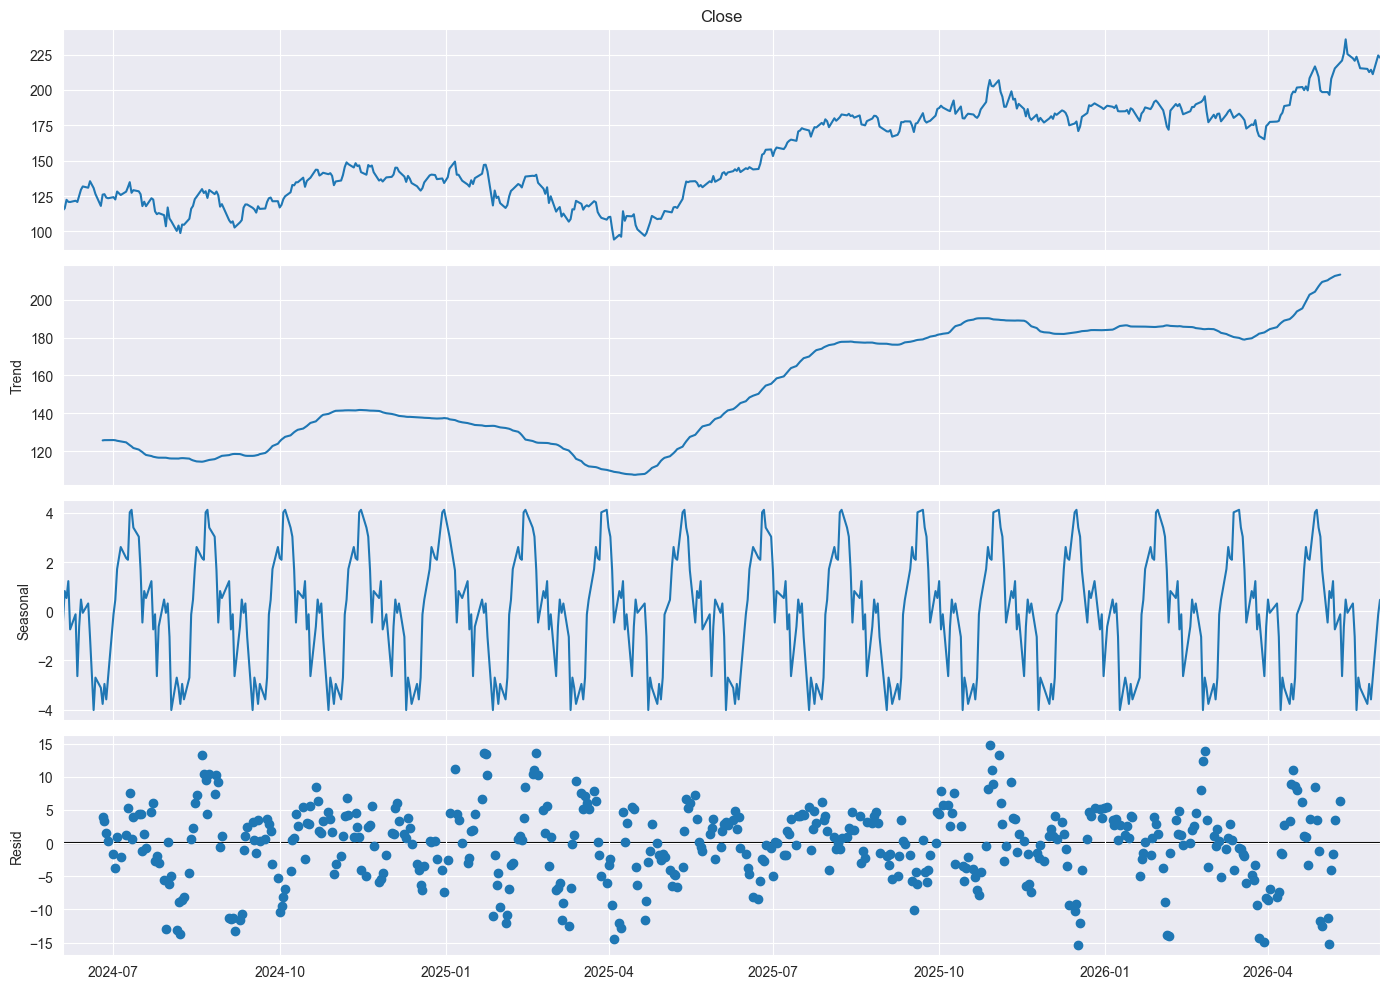

In [72]:
result = seasonal_decompose(df["Close"], model="additive", period=30)

# Cambias el tamaño default de todas las figuras
plt.rcParams['figure.figsize'] = (14, 10)  # ancho, alto en pulgadas

result.plot()
plt.tight_layout()
plt.show()

# Regresas al tamaño normal si quieres
plt.rcParams['figure.figsize'] = plt.rcParamsDefault['figure.figsize']

📌 Interpretación: Análisis de frecuencia (Fourier Transform)

* 🔵 picos altos → ciclos fuertes en el mercado
* 🔵 frecuencias bajas → tendencias largas
* 🔵 frecuencias altas → ruido / microestructura

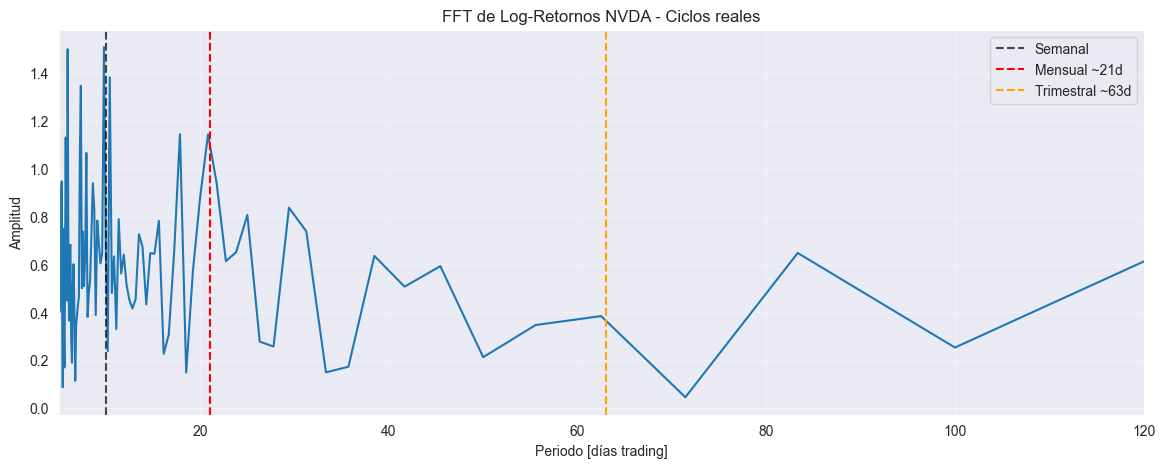

Top ciclos en retornos NVDA:
Periodo: 9.8 días, Amplitud: 1.51
Periodo: 6.0 días, Amplitud: 1.50
Periodo: 10.4 días, Amplitud: 1.38
Periodo: 7.4 días, Amplitud: 1.35
Periodo: 17.9 días, Amplitud: 1.14


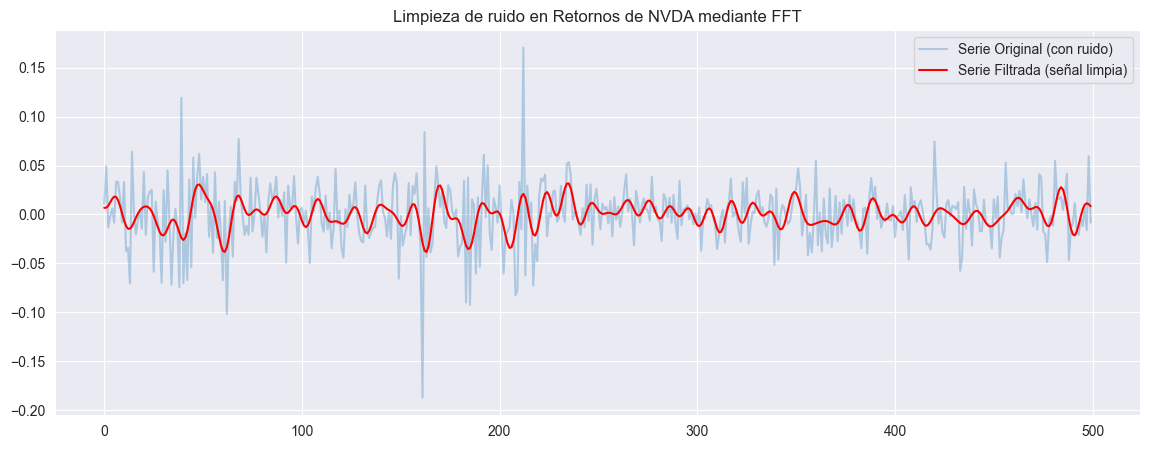

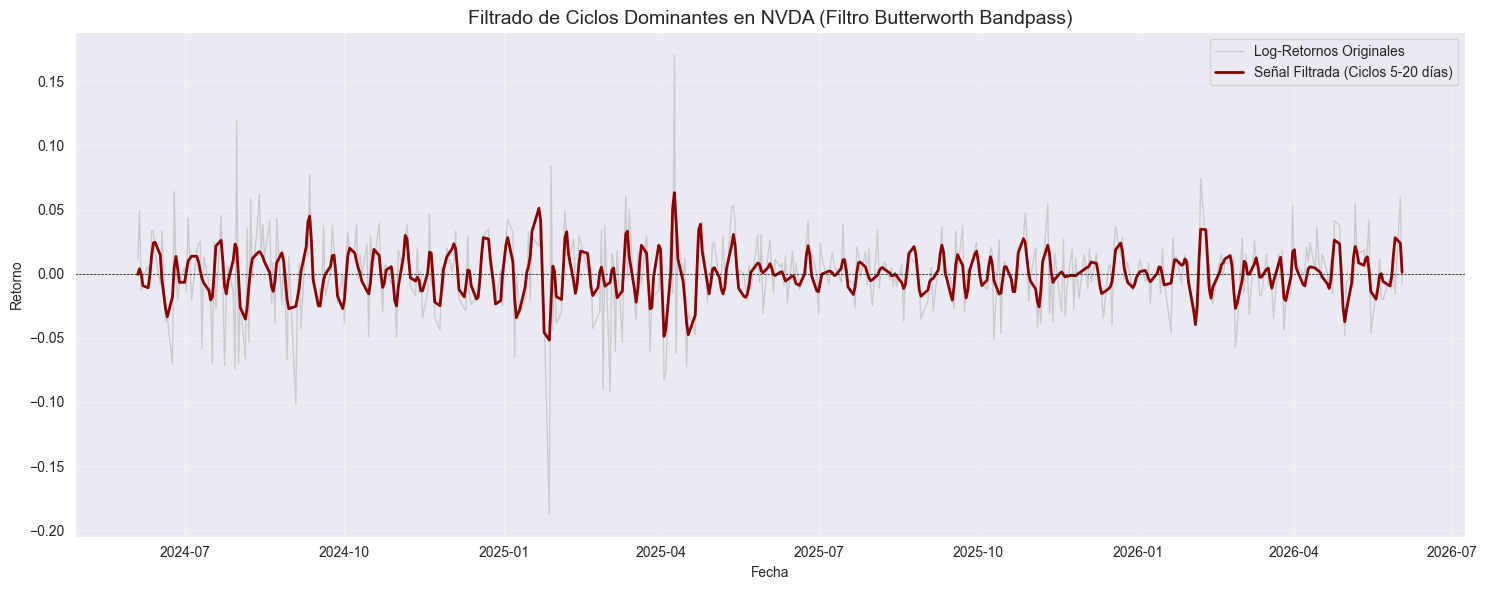

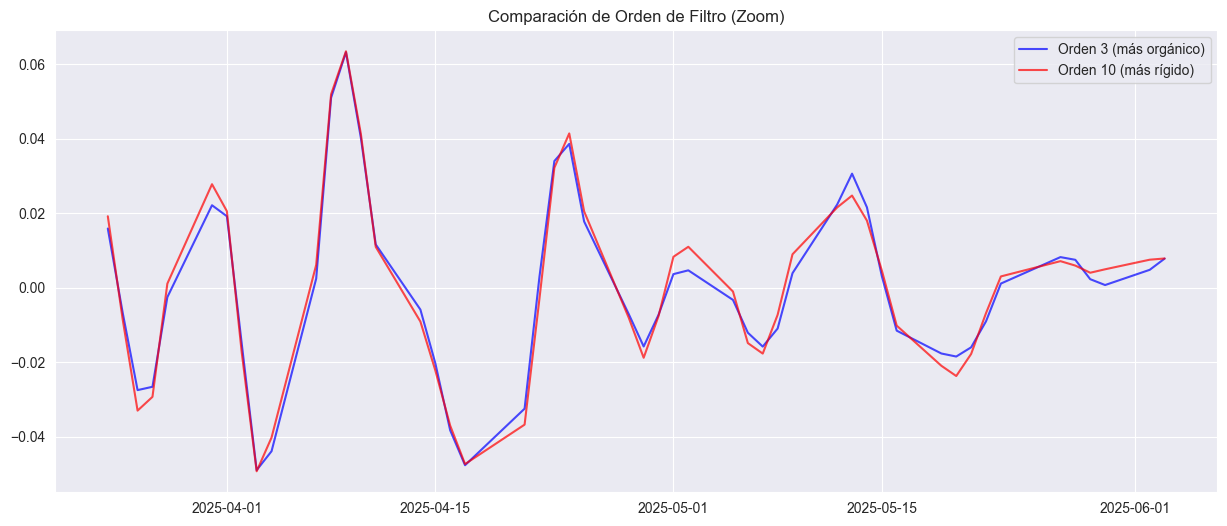

Correlación Orden 3: 0.593
Correlación Orden 10: 0.566


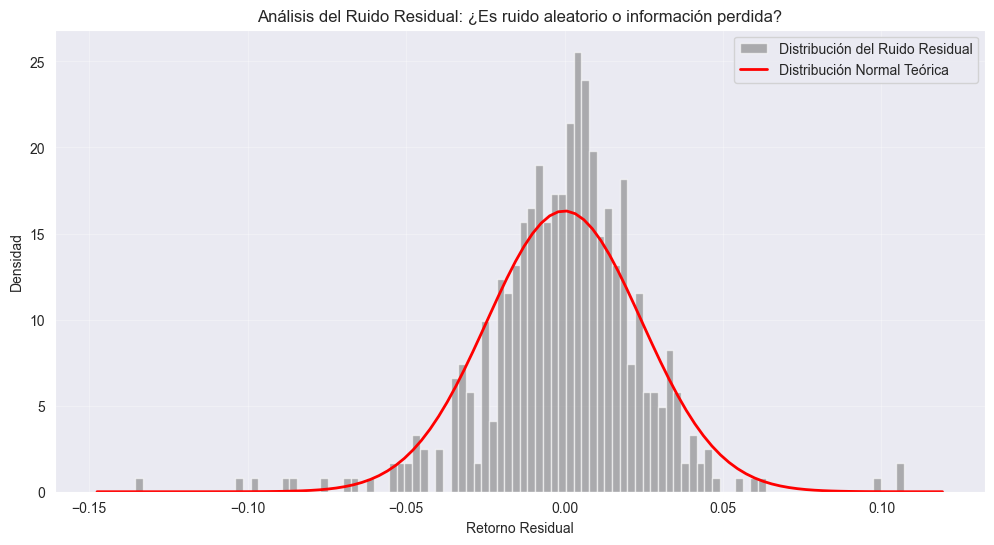

Desviación estándar del ruido residual: 0.0245
Media del residuo: -0.000091
Desviación estándar del ruido (sigma): 0.0245
Umbral de 3-sigma (Límite de riesgo extremo): +/- 0.0734
Porcentaje de días que NVDA se salió del patrón cíclico (Eventos Extremos): 1.80%


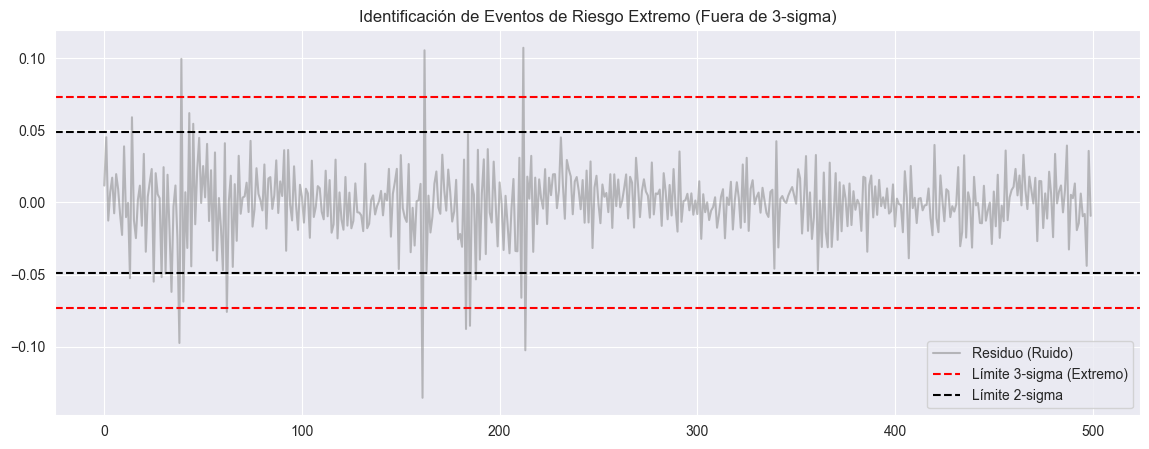

Ciclo dentro de límites normales.


In [110]:
# 1. LOG RETURNS:
log_returns = np.log(df['Close']).diff().dropna()

# 2. Opcional: quita la media. FFT asume media 0
log_returns = log_returns - log_returns.mean()

n = len(log_returns)

fft_vals = np.fft.fft(log_returns.values)
freqs = np.fft.fftfreq(n, d=1) # d=1 día

magnitude = np.abs(fft_vals)
pos = (freqs > 0) & (freqs < 0.2) # solo ciclos > 5 días

periods = 1 / freqs[pos]

plt.figure(figsize=(14,5))
plt.plot(periods, magnitude[pos])
plt.title('FFT de Log-Retornos NVDA - Ciclos reales')
plt.xlabel('Periodo [días trading]')
plt.ylabel('Amplitud')
plt.axvline(10, color='black', linestyle='--', alpha=0.7, label='Semanal')
plt.axvline(21, color='red', linestyle='--', label='Mensual ~21d')
plt.axvline(63, color='orange', linestyle='--', label='Trimestral ~63d')
plt.xlim(5, 120)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Top ciclos > 5 días
top_idx = np.argsort(magnitude[pos])[-5:]
print("Top ciclos en retornos NVDA:")
for i in top_idx[::-1]: # de mayor a menor
    print(f"Periodo: {periods[i]:.1f} días, Amplitud: {magnitude[pos][i]:.2f}")
    
    
# 2. Definir el umbral de corte (Cut-off)
# Todo lo que tenga una frecuencia superior a 'cutoff' será eliminado
# Ejemplo: queremos eliminar ciclos menores a 10 días (ruido diario)
cutoff_freq = 1/10  

# 3. Crear una máscara de filtro
# Ponemos a cero las frecuencias que consideramos ruido
fft_filtered = fft_vals.copy()
fft_filtered[np.abs(freqs) > cutoff_freq] = 0

# 4. Reconstruir la señal con la transformada inversa
clean_log_returns = np.fft.ifft(fft_filtered).real

# Visualización comparativa
plt.figure(figsize=(14,5))
plt.plot(log_returns.values, label='Serie Original (con ruido)', alpha=0.3)
plt.plot(clean_log_returns, label='Serie Filtrada (señal limpia)', color='red', linewidth=1.5)
plt.legend()
plt.title('Limpieza de ruido en Retornos de NVDA mediante FFT')
plt.show()


def butter_bandpass_filter(data, period_low, period_high, fs=1.0, order=3):
    freq_high = 1.0 / period_low
    freq_low = 1.0 / period_high
    nyq = 0.5 * fs
    low = freq_low / nyq
    high = freq_high / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# 2. Aplicar el filtro (ciclos entre 5 y 20 días)
# Usamos un 'order=3' para evitar que el filtro sea demasiado agresivo
clean_signal = butter_bandpass_filter(log_returns.values, 5, 20, fs=1.0,order=3)

# 3. Graficar
plt.figure(figsize=(15, 6))

# Plot de la serie original (más tenue)
plt.plot(log_returns.index, log_returns.values, label='Log-Retornos Originales', 
         color='gray', alpha=0.3, linewidth=1)

# Plot de la señal filtrada (la tendencia cíclica)
plt.plot(log_returns.index, clean_signal, label='Señal Filtrada (Ciclos 5-20 días)', 
         color='darkred', linewidth=2)

plt.title('Filtrado de Ciclos Dominantes en NVDA (Filtro Butterworth Bandpass)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()  



# Generar ambos
signal_low = butter_bandpass_filter(log_returns.values, 5, 20, fs=1.0, order=3)
signal_high = butter_bandpass_filter(log_returns.values, 5, 20, fs=1.0, order=10)

plt.figure(figsize=(15, 6))
# Zoom a un periodo de 50 días para ver la diferencia
inicio, fin = 200, 250 

plt.plot(log_returns.index[inicio:fin], signal_low[inicio:fin], 
         label='Orden 3 (más orgánico)', color='blue', alpha=0.7)
plt.plot(log_returns.index[inicio:fin], signal_high[inicio:fin], 
         label='Orden 10 (más rígido)', color='red', alpha=0.7)
plt.legend()
plt.title('Comparación de Orden de Filtro (Zoom)')
plt.show()

corr_orden3 = np.corrcoef(log_returns.values, signal_low)[0, 1]
corr_orden10 = np.corrcoef(log_returns.values, signal_high)[0, 1]

print(f"Correlación Orden 3: {corr_orden3:.3f}")
print(f"Correlación Orden 10: {corr_orden10:.3f}")

# 1. Calcular el residuo (lo que el filtro eliminó)
residuo = log_returns.values - clean_signal

# 2. Graficar el histograma del residuo
plt.figure(figsize=(12, 6))
plt.hist(residuo, bins=100, color='gray', alpha=0.6, density=True, label='Distribución del Ruido Residual')

# 3. Comparar con una Normal para ver si hay 'colas pesadas' (eventos extremos)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, np.mean(residuo), np.std(residuo))
plt.plot(x, p, 'r', linewidth=2, label='Distribución Normal Teórica')

plt.title('Análisis del Ruido Residual: ¿Es ruido aleatorio o información perdida?')
plt.xlabel('Retorno Residual')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Estadísticas clave
print(f"Desviación estándar del ruido residual: {np.std(residuo):.4f}")
print(f"Media del residuo: {np.mean(residuo):.6f}")  


# 1. Definir umbrales de volatilidad (Z-score)
sigma = np.std(residuo)
umbral_2sigma = 2 * sigma
umbral_3sigma = 3 * sigma

# 2. Identificar cuántos eventos superan el umbral
eventos_extremos = residuo[np.abs(residuo) > umbral_3sigma]
total_dias = len(residuo)
porcentaje_extremos = (len(eventos_extremos) / total_dias) * 100

print(f"Desviación estándar del ruido (sigma): {sigma:.4f}")
print(f"Umbral de 3-sigma (Límite de riesgo extremo): +/- {umbral_3sigma:.4f}")
print(f"Porcentaje de días que NVDA se salió del patrón cíclico (Eventos Extremos): {porcentaje_extremos:.2f}%")

# 3. Graficar los umbrales sobre el residuo
plt.figure(figsize=(14, 5))
plt.plot(residuo, color='gray', alpha=0.5, label='Residuo (Ruido)')
plt.axhline(umbral_3sigma, color='red', linestyle='--', label='Límite 3-sigma (Extremo)')
plt.axhline(-umbral_3sigma, color='red', linestyle='--')
plt.axhline(umbral_2sigma, color='black', linestyle='--', label='Límite 2-sigma')
plt.axhline(-umbral_2sigma, color='black', linestyle='--')
plt.title('Identificación de Eventos de Riesgo Extremo (Fuera de 3-sigma)')
plt.legend()
plt.show()

def check_risk_alert(current_residuo, threshold):
    """
    Devuelve una señal de advertencia si el residuo supera el umbral.
    """
    if abs(current_residuo) > threshold:
        return {
            "alerta": True, 
            "mensaje": "⚠️ ALERTA DE RIESGO EXTREMO: Movimiento no cíclico detectado.",
            "severidad": "Alta"
        }
    return {"alerta": False, "mensaje": "Ciclo dentro de límites normales.", "severidad": "Baja"}

# Ejemplo de uso en tu loop de trading o análisis:
# 'residuo' es tu serie calculada (log_returns - clean_signal)
# 'umbral_3sigma' es el valor que ya calculaste

# Si quisieras revisar el último dato del mercado:
ultima_alerta = check_risk_alert(residuo[-1], umbral_3sigma)
print(ultima_alerta["mensaje"]) 



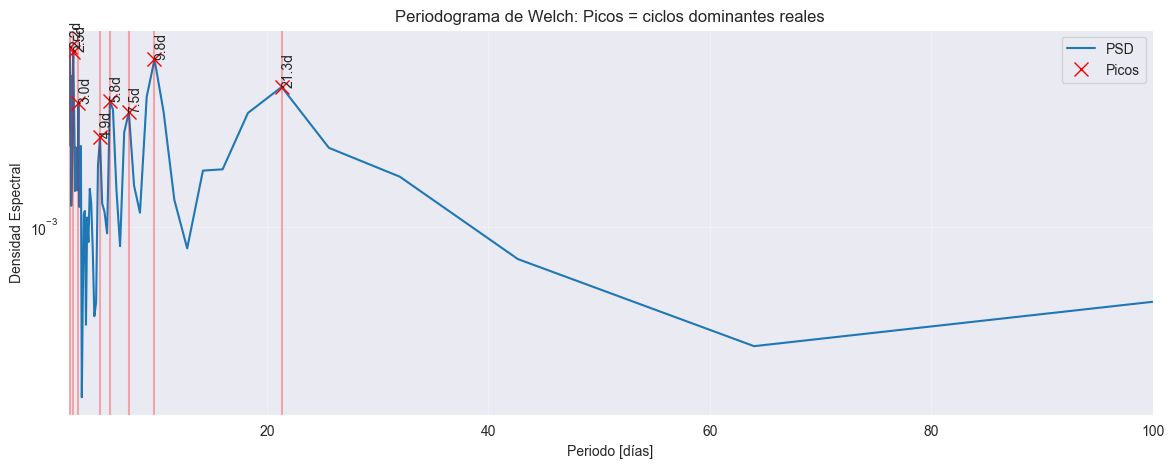

Ciclos dominantes detectados automáticamente:
21.3 días
9.8 días
7.5 días
5.8 días
4.9 días
3.0 días
2.5 días
2.2 días


In [117]:
from scipy.signal import welch, find_peaks

# 1. Log returns
log_returns = np.log(df['Close']).diff().dropna()
log_returns = log_returns - log_returns.mean()

# 2. Welch
freqs, psd = welch(log_returns.values, fs=1.0, nperseg=128)
periods = 1 / freqs[1:]
psd = psd[1:]

# 3. Picos
peaks, properties = find_peaks(psd, prominence=np.std(psd))

plt.figure(figsize=(14,5))
plt.semilogy(periods, psd, label='PSD')
plt.plot(periods[peaks], psd[peaks], "x", color='red', ms=10, label='Picos')
plt.xlabel('Periodo [días]')
plt.ylabel('Densidad Espectral')
plt.title('Periodograma de Welch: Picos = ciclos dominantes reales')
plt.xlim(2, 100)

# ✅ Forma correcta de iterar
for period, amplitude in zip(periods[peaks], psd[peaks]):
    plt.axvline(period, color='red', alpha=0.3)
    plt.text(period, amplitude, f'{period:.1f}d', rotation=90, va='bottom')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Ciclos dominantes detectados automáticamente:")
for p in periods[peaks]:
    print(f"{p:.1f} días")

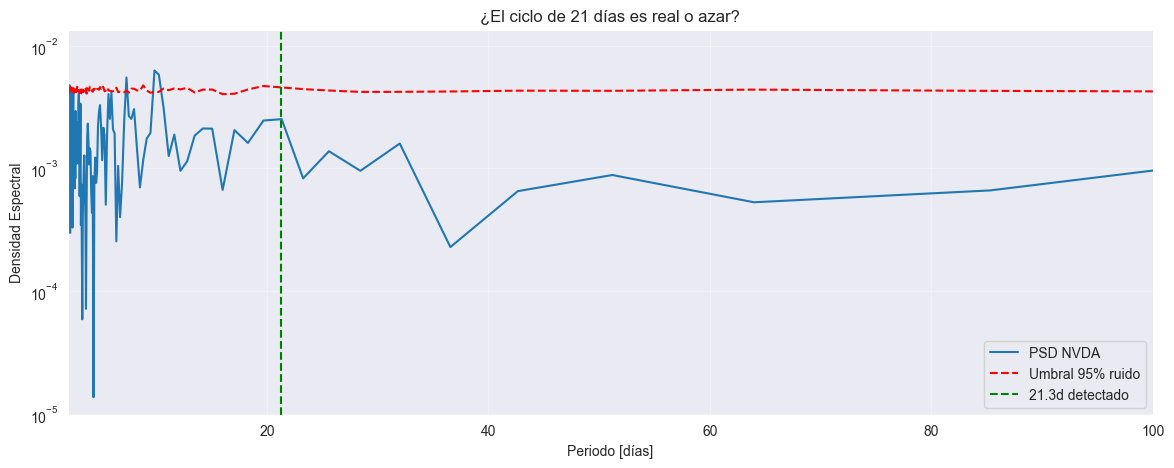

PSD en 21.3d: 2.52e-03
Umbral 95% ruido: 4.58e-03
Ratio: 0.55x
¿Significativo al 95%?: False


In [119]:
from scipy.signal import welch, find_peaks

log_returns = np.log(df['Close']).diff().dropna()
log_returns = log_returns - log_returns.mean()
n = len(log_returns)

# 1. PSD real de NVDA
freqs, psd = welch(log_returns.values, fs=1.0, nperseg=256)
valid = (freqs > 0) & (freqs < 0.5)
freqs, psd = freqs[valid], psd[valid]
periods = 1 / freqs

# 2. Simula 1000 series de ruido blanco con misma volatilidad
n_sim = 1000
null_psd = []
std = log_returns.std()
for _ in range(n_sim):
    fake = np.random.normal(0, std, n)
    f, p = welch(fake, fs=1.0, nperseg=256)
    null_psd.append(p[valid])
    
null_95 = np.percentile(null_psd, 95, axis=0) # umbral 95%

# 3. Plot
plt.figure(figsize=(14,5))
plt.semilogy(periods, psd, label='PSD NVDA')
plt.semilogy(periods, null_95, 'r--', label='Umbral 95% ruido')
plt.axvline(21.3, color='green', ls='--', label='21.3d detectado')
plt.xlim(2, 100)
plt.xlabel('Periodo [días]')
plt.ylabel('Densidad Espectral')
plt.title('¿El ciclo de 21 días es real o azar?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Chequeo numérico
idx_21 = np.argmin(np.abs(periods - 21.3))
es_significativo = psd[idx_21] > null_95[idx_21]
ratio = psd[idx_21] / null_95[idx_21]

print(f"PSD en 21.3d: {psd[idx_21]:.2e}")
print(f"Umbral 95% ruido: {null_95[idx_21]:.2e}")
print(f"Ratio: {ratio:.2f}x")
print(f"¿Significativo al 95%?: {es_significativo}")

* Se rechaza la hipotesis de que nvda tenga ciclos de 21.3 dias.

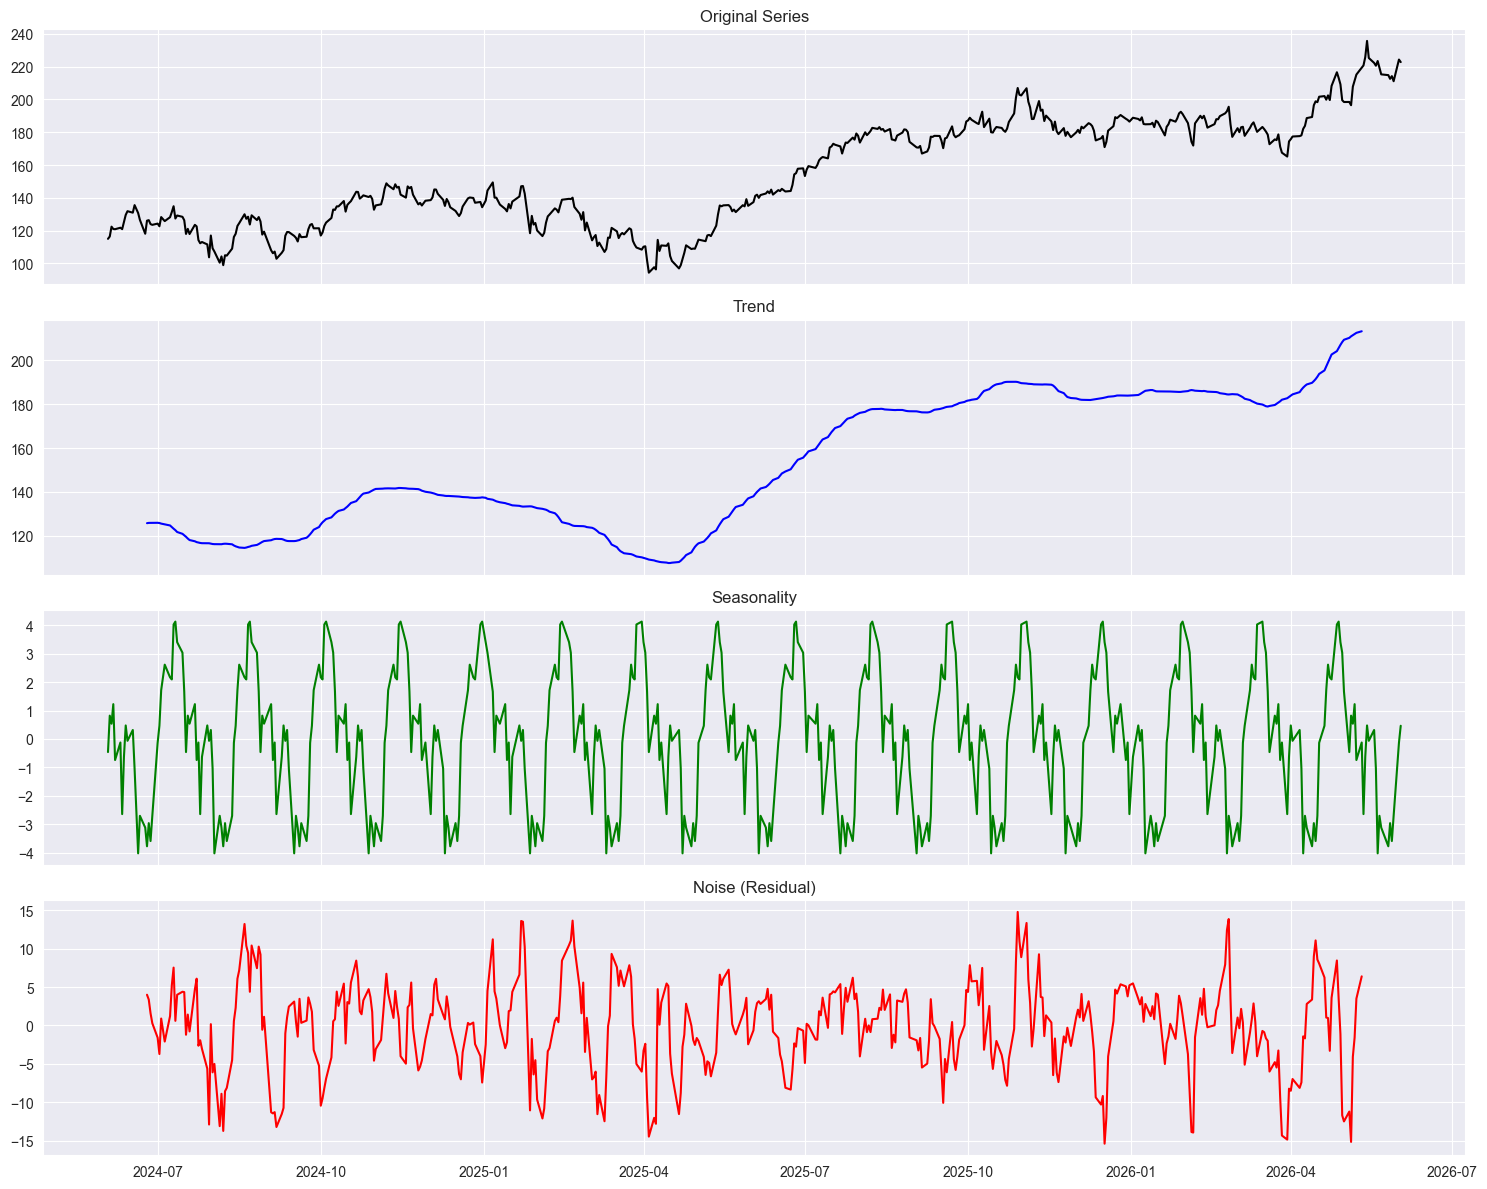

In [120]:
df["Trend"] = result.trend
df["Seasonal"] = result.seasonal
df["Residual"] = result.resid

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(df.index, df["Close"], color="black")
axes[0].set_title("Original Series")

axes[1].plot(df.index, df["Trend"], color="blue")
axes[1].set_title("Trend")

axes[2].plot(df.index, df["Seasonal"], color="green")
axes[2].set_title("Seasonality")

axes[3].plot(df.index, df["Residual"], color="red")
axes[3].set_title("Noise (Residual)")

plt.tight_layout()
plt.show()

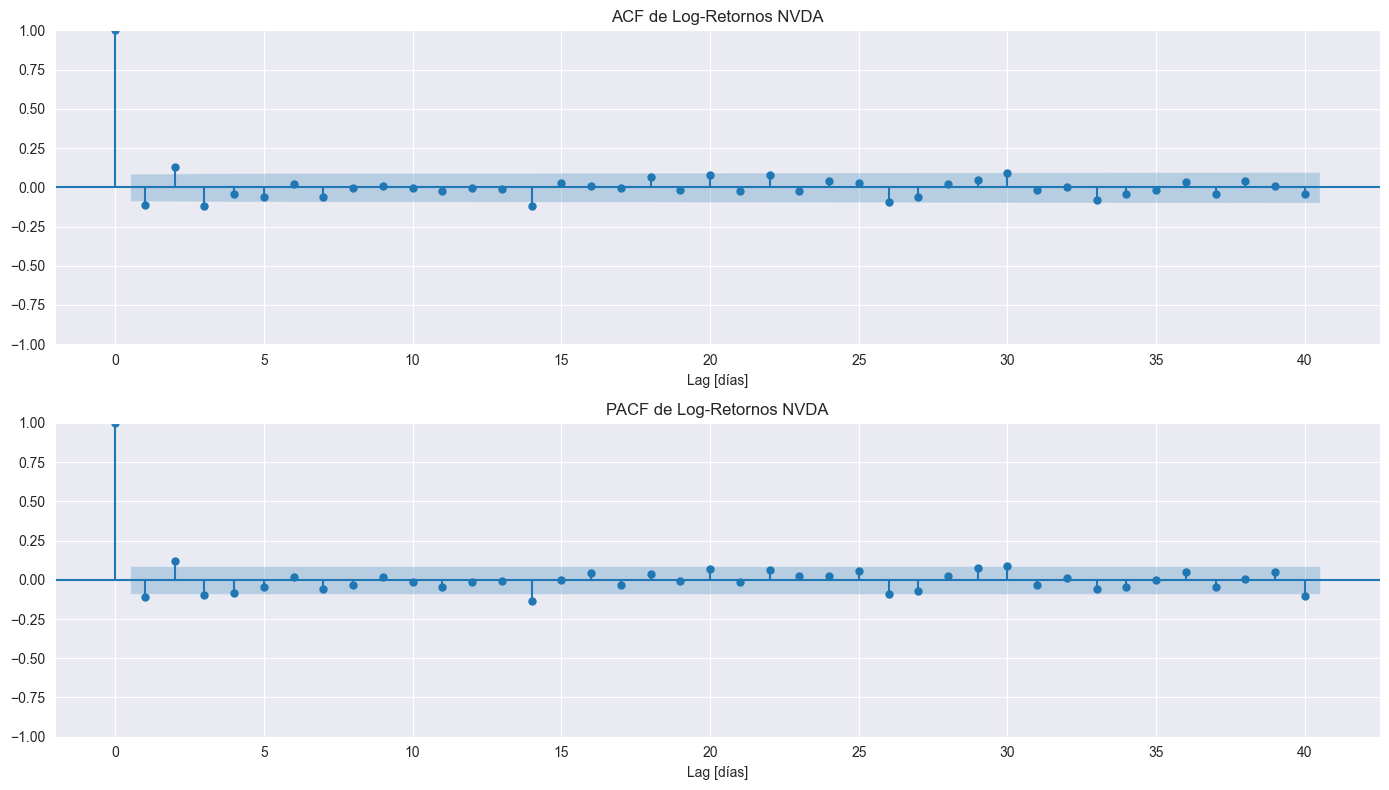

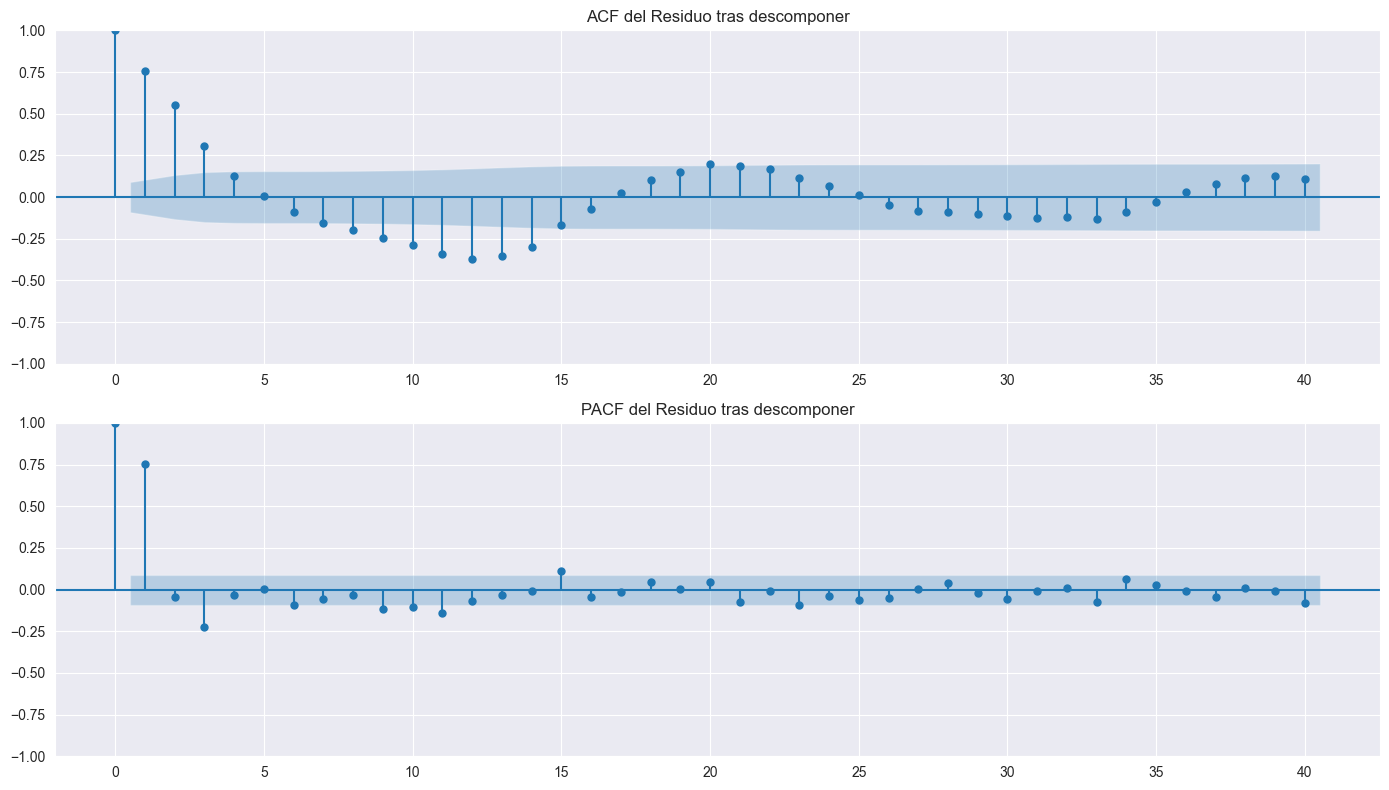

In [122]:
# OPCIÓN 1: ACF/PACF de log-retornos - lo correcto para NVDA
log_returns = np.log(df['Close']).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(log_returns, lags=40, ax=axes[0])
axes[0].set_title('ACF de Log-Retornos NVDA')
axes[0].set_xlabel('Lag [días]')

plot_pacf(log_returns, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF de Log-Retornos NVDA')
axes[1].set_xlabel('Lag [días]')

plt.tight_layout()
plt.show()

# OPCIÓN 2: ACF/PACF del residuo si ya quitaste tendencia
residuo_estacionario = df['Residual'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(residuo_estacionario, lags=40, ax=axes[0])
axes[0].set_title('ACF del Residuo tras descomponer')
plot_pacf(residuo_estacionario, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF del Residuo tras descomponer')
plt.tight_layout()
plt.show()

In [125]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

def test_estacionaria(serie, nombre):
    result = adfuller(serie.dropna(), autolag='AIC')
    print(f"--- ADF Test: {nombre} ---")
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.4f}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f' {key}: {value:.3f}')

    if result[1] <= 0.05:
        print("Conclusión: ✅ Rechazas H0. La serie ES estacionaria\n")
    else:
        print("Conclusión: ❌ No rechazas H0. La serie NO es estacionaria\n")

    return result[1]

# 1. Test en precios - debería fallar
test_estacionaria(df['Close'], "Precio Close NVDA")

# 2. Test en log-retornos - debería pasar
log_returns = np.log(df['Close']).diff().dropna()
test_estacionaria(log_returns, "Log-Retornos NVDA")

# 3. Test en tu residuo del filtro - va a pasar pero es trampa
test_estacionaria(df['Residual'].dropna(), "Residuo tras descomponer")

--- ADF Test: Precio Close NVDA ---
ADF Statistic: -0.570
p-value: 0.8776
Valores Críticos:
 1%: -3.444
 5%: -2.867
 10%: -2.570
Conclusión: ❌ No rechazas H0. La serie NO es estacionaria

--- ADF Test: Log-Retornos NVDA ---
ADF Statistic: -12.482
p-value: 0.0000
Valores Críticos:
 1%: -3.444
 5%: -2.867
 10%: -2.570
Conclusión: ✅ Rechazas H0. La serie ES estacionaria

--- ADF Test: Residuo tras descomponer ---
ADF Statistic: -6.599
p-value: 0.0000
Valores Críticos:
 1%: -3.445
 5%: -2.868
 10%: -2.570
Conclusión: ✅ Rechazas H0. La serie ES estacionaria



np.float64(6.824688743386928e-09)

| Test          | NVDA              | KO/XLU                        | Decisión                        |
|---------------|-------------------|-------------------------------|---------------------------------|
| ADF Close     | No estacionaria   | No estacionaria               | Normal                          |
| ADF Returns   | Estacionaria      | Estacionaria                  | Normal                          |
| ACF Returns   | Sin lags          | Lag 5, 21, 63 fuera           | NVDA = ruido, KO = ciclos       |
| Welch PSD     | Ratio 0.54x       | Ratio > 1.5x                  | NVDA = no cíclica               |


| Test                        | Resultado                | Veredicto             |
|-----------------------------|--------------------------|-----------------------|
| Welch PSD vs ruido          | Ratio 0.54x              | No hay ciclos         |
| ACF retornos                | Todo dentro de bandas    | No hay memoria        |
| ACF residuo tras filtro     | Autocorrelación fuerte   | Artefacto del filtro  |


## **Anlizar Consumo de Conbustible Mensual**

In [3]:
url='https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/consumos-combustibles-mensual.csv'
df=pd.read_csv(url,sep=',')
df.head()

,Fecha,GLPs,Gasolinas,Querosenos,Gasoleos,Fueloleos
0,1969-01-01,133615.09620,166875.2129,123257.8090,401185.2939,912583.4202
1,1969-02-01,126748.47410,155466.8105,114682.5767,385360.0381,851877.8115
2,1969-03-01,107795.80910,184983.6699,109970.0796,418955.5808,873884.2933
3,1969-04-01,96683.15967,202319.8164,108797.9255,438975.5445,755490.1170
4,1969-05-01,79506.23804,206259.1523,103554.0784,467451.9469,729963.6009


In [7]:
df['Fecha']=pd.to_datetime(df['Fecha'],format='%Y-%m-%d',errors='coerce')
print(df['Fecha'].isnull().sum())

0


In [8]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

def test_estacionaria(serie, nombre):
    result = adfuller(serie.dropna(), autolag='AIC')
    print(f"--- ADF Test: {nombre} ---")
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.4f}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f' {key}: {value:.3f}')

    if result[1] <= 0.05:
        print("Conclusión: ✅ Rechazas H0. La serie ES estacionaria\n")
    else:
        print("Conclusión: ❌ No rechazas H0. La serie NO es estacionaria\n")

    return result[1]

--- ADF Test: Precio Gasolina Mensual ---
ADF Statistic: -1.896
p-value: 0.3338
Valores Críticos:
 1%: -3.441
 5%: -2.866
 10%: -2.569
Conclusión: ❌ No rechazas H0. La serie NO es estacionaria

--- ADF Test: Diferencia de 1, Consumo de la Gasolina Mensual ---
ADF Statistic: -4.659
p-value: 0.0001
Valores Críticos:
 1%: -3.441
 5%: -2.866
 10%: -2.569
Conclusión: ✅ Rechazas H0. La serie ES estacionaria

--- ADF Test: Diferencia de 2 , Consumo de la Gasolina Mensual ---
ADF Statistic: -8.961
p-value: 0.0000
Valores Críticos:
 1%: -3.441
 5%: -2.866
 10%: -2.569
Conclusión: ✅ Rechazas H0. La serie ES estacionaria



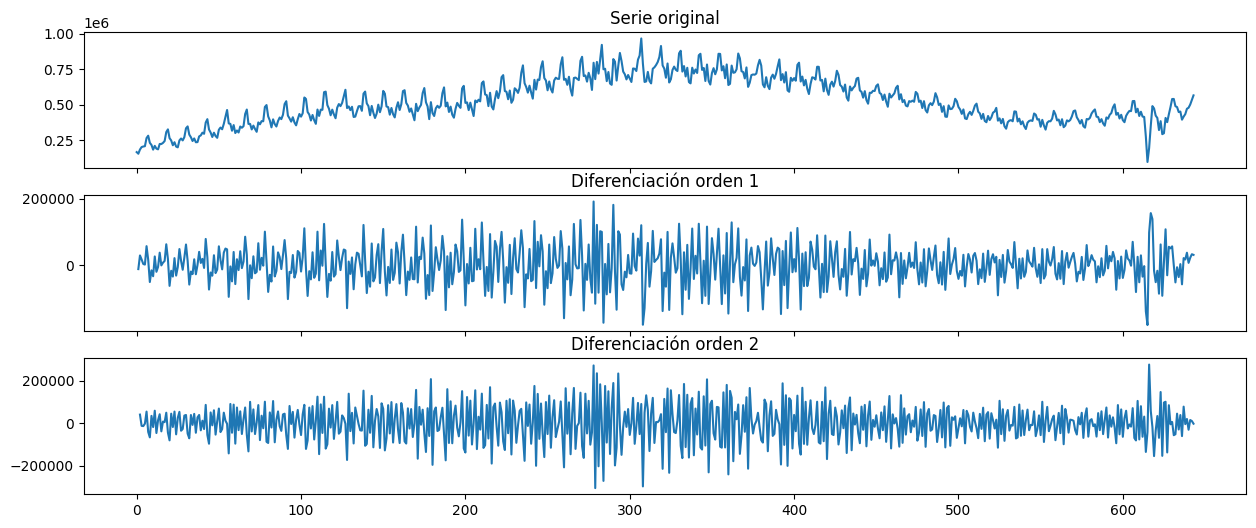

In [21]:
# # 2. Test en log-retornos - debería pasar
test_estacionaria(df['Gasolinas'], "Precio Gasolina Mensual") # La series no estacionaria
datos_diff_1=df['Gasolinas'].diff().dropna()
test_estacionaria(datos_diff_1, "Diferencia de 1, Consumo de la Gasolina Mensual")
datos_diff_2=datos_diff_1.diff().dropna()
test_estacionaria(datos_diff_2,"Diferencia de 2 , Consumo de la Gasolina Mensual")

# Graficos de series 
fig,axs=plt.subplots(nrows=3,ncols=1,figsize=(15,6),sharex=True)
df['Gasolinas'].plot(ax=axs[0], title='Serie original')
datos_diff_1.plot(ax=axs[1], title='Diferenciación orden 1')
datos_diff_2.plot(ax=axs[2], title='Diferenciación orden 2')
plt.show()

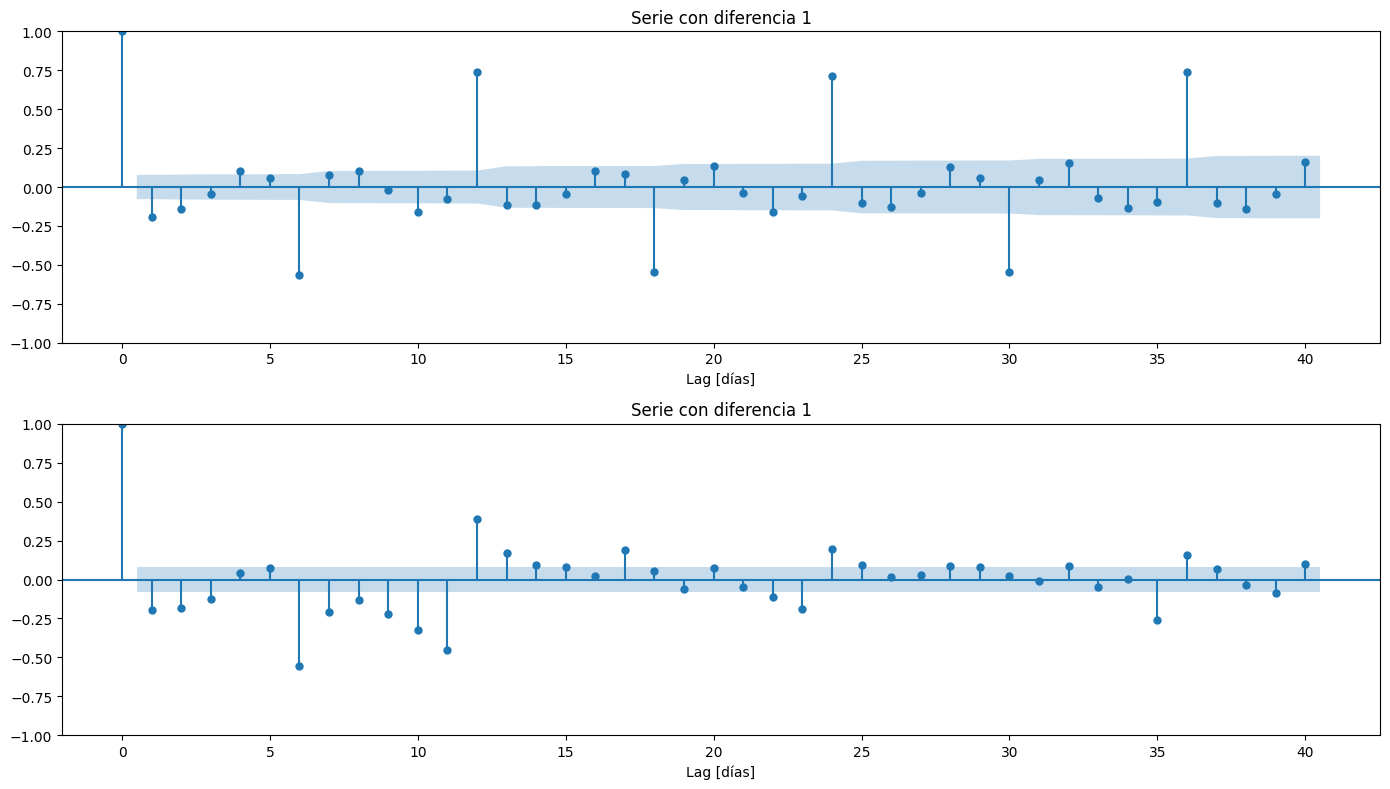

In [24]:
# OPCIÓN 1: ACF/PACF de log-retornos - lo correcto para NVDA
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(datos_diff_1, lags=40, ax=axes[0])
axes[0].set_title('Serie con diferencia 1')
axes[0].set_xlabel('Lag [días]')

plot_pacf(datos_diff_1, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Serie con diferencia 1')
axes[1].set_xlabel('Lag [días]')

plt.tight_layout()
plt.show()

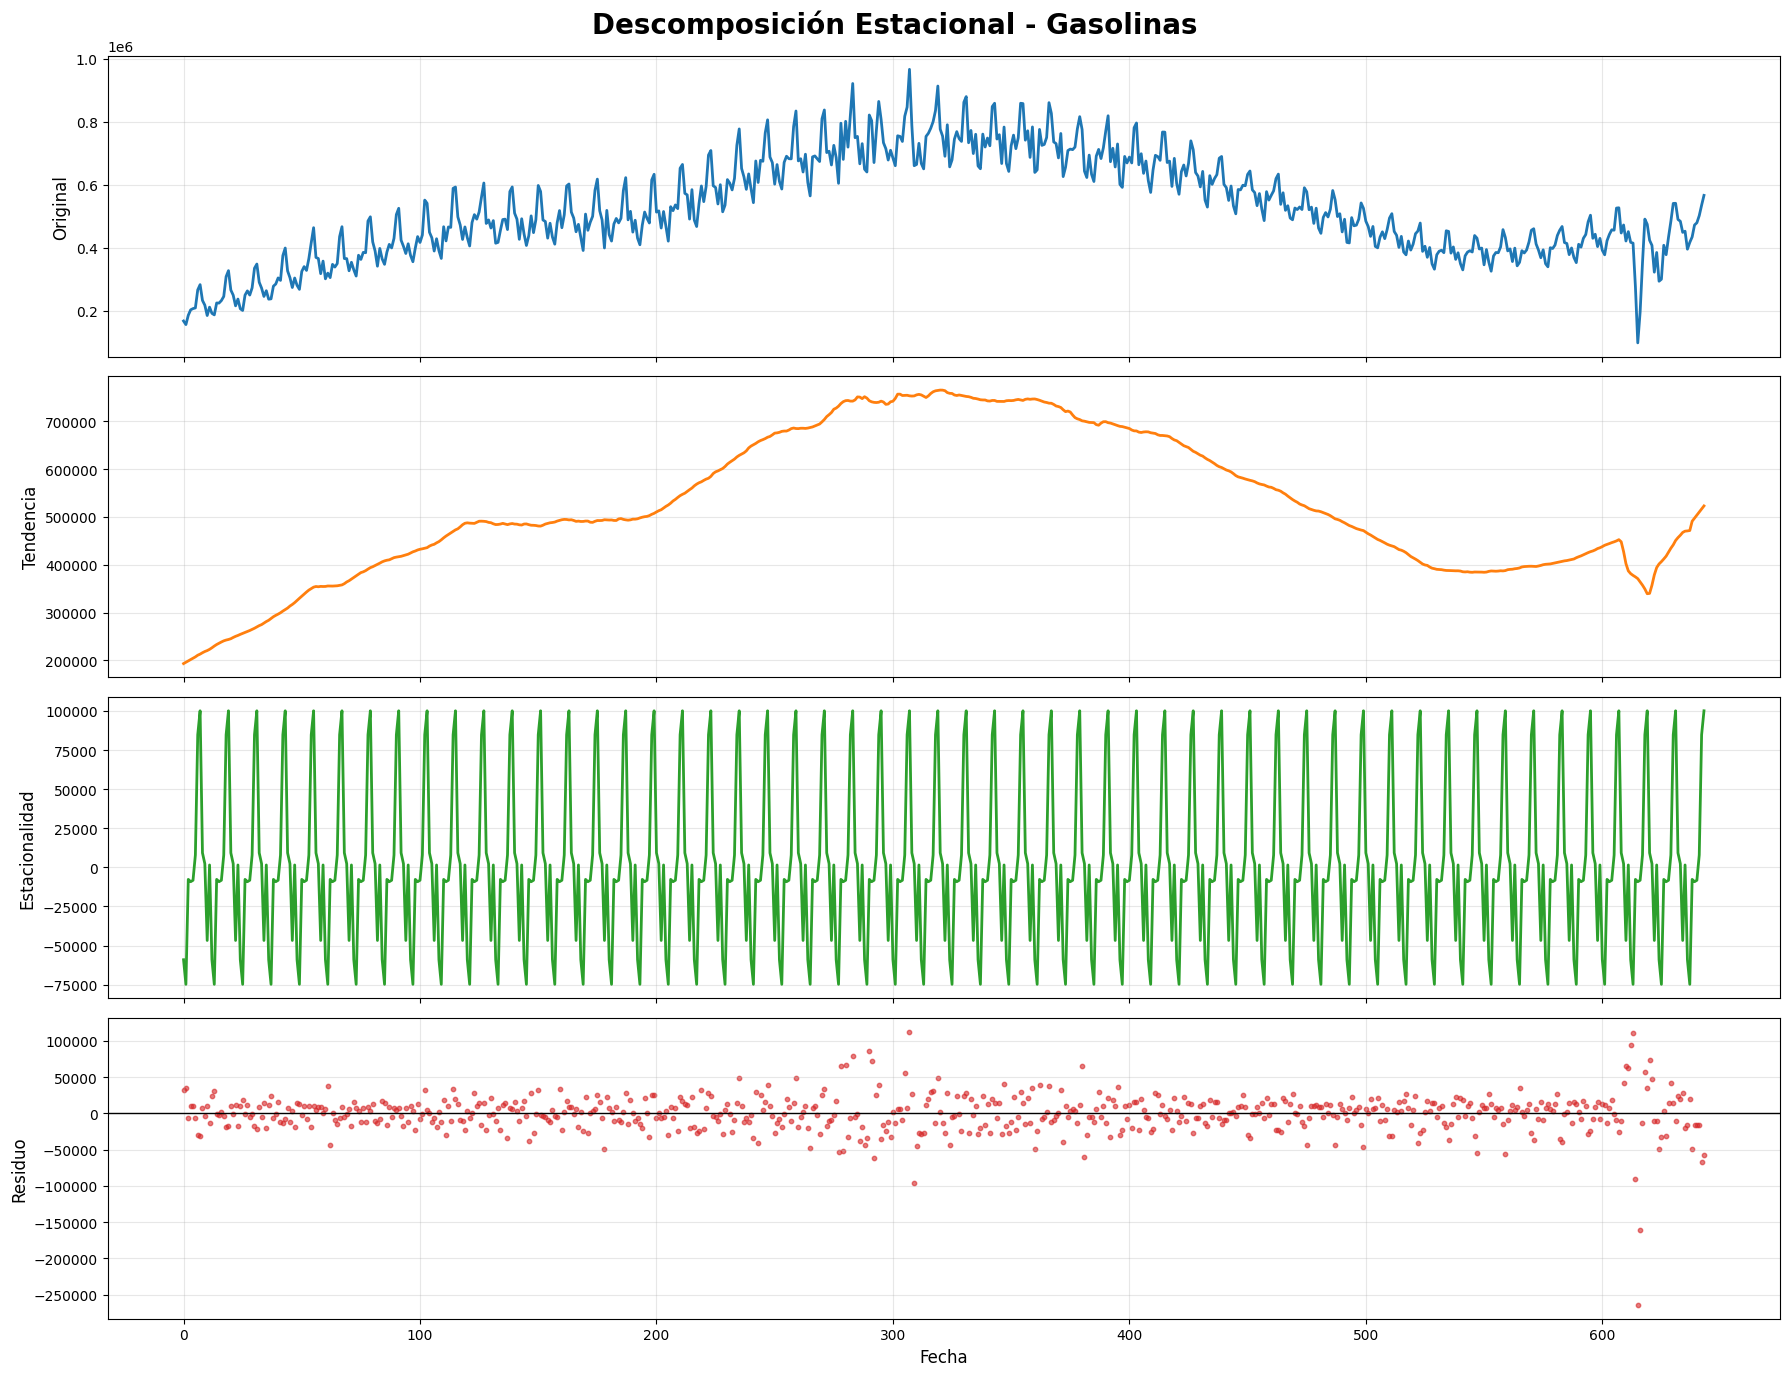

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

datos = df[['Gasolinas']]

result = seasonal_decompose(
    datos, 
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

# Creas la figura tú mismo
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True, dpi=100)
fig.suptitle('Descomposición Estacional - Gasolinas', fontsize=20, weight='bold')

# Plot manual de cada componente
axes[0].plot(result.observed, color='#1f77b4', lw=2)
axes[0].set_ylabel('Original', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.trend, color='#ff7f0e', lw=2)
axes[1].set_ylabel('Tendencia', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(result.seasonal, color='#2ca02c', lw=2)
axes[2].set_ylabel('Estacionalidad', fontsize=12)
axes[2].grid(True, alpha=0.3)

axes[3].scatter(result.resid.index, result.resid, color='#d62728', s=10, alpha=0.6)
axes[3].axhline(0, color='black', lw=1)
axes[3].set_ylabel('Residuo', fontsize=12)
axes[3].set_xlabel('Fecha', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

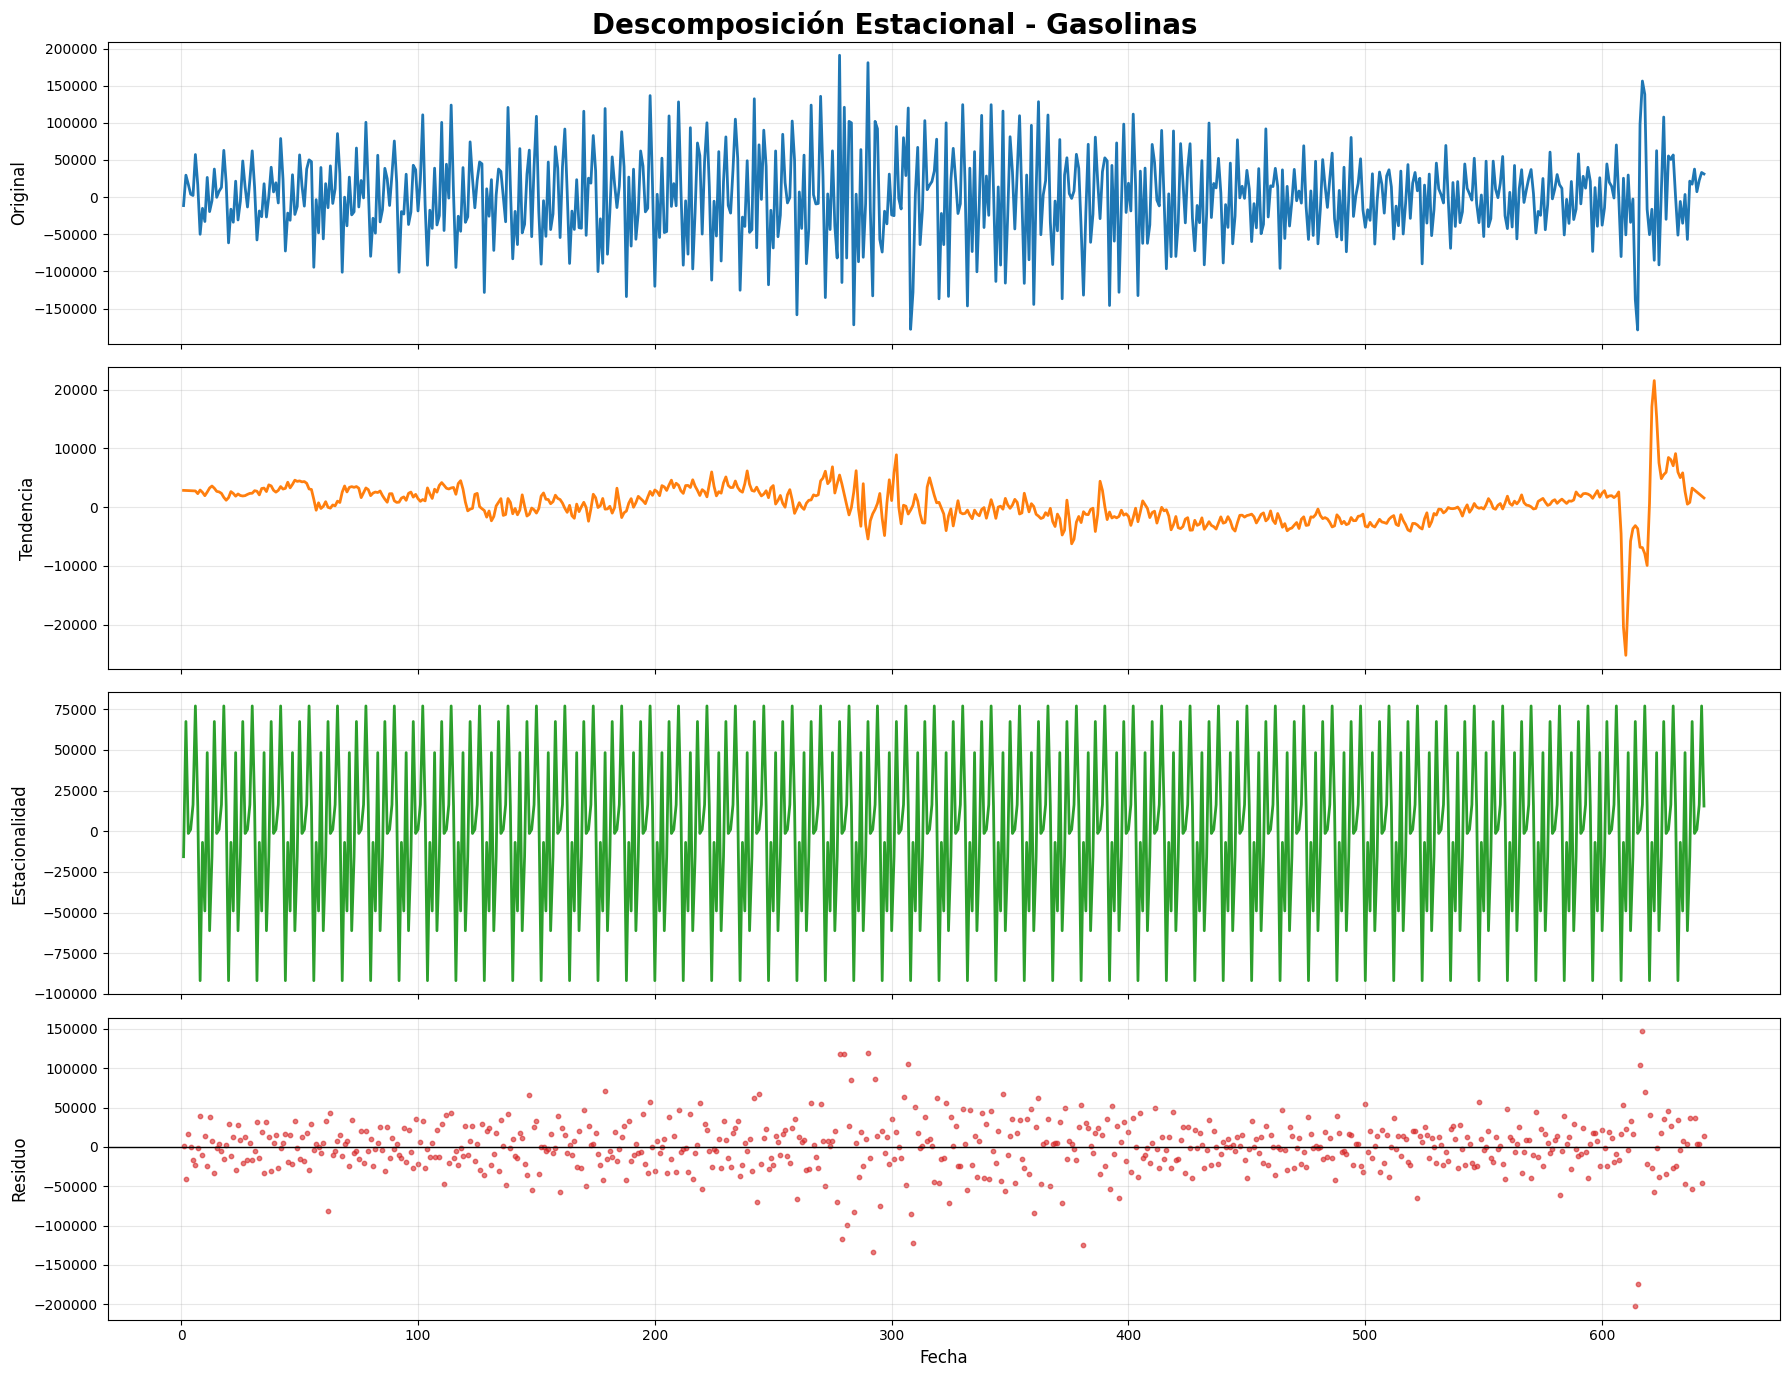

In [37]:
result = seasonal_decompose(
    datos_diff_1, 
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

# Creas la figura tú mismo
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True, dpi=100)
fig.suptitle('Descomposición Estacional - Gasolinas', fontsize=20, weight='bold')

# Plot manual de cada componente
axes[0].plot(result.observed, color='#1f77b4', lw=2)
axes[0].set_ylabel('Original', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.trend, color='#ff7f0e', lw=2)
axes[1].set_ylabel('Tendencia', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(result.seasonal, color='#2ca02c', lw=2)
axes[2].set_ylabel('Estacionalidad', fontsize=12)
axes[2].grid(True, alpha=0.3)

axes[3].scatter(result.resid.index, result.resid, color='#d62728', s=10, alpha=0.6)
axes[3].axhline(0, color='black', lw=1)
axes[3].set_ylabel('Residuo', fontsize=12)
axes[3].set_xlabel('Fecha', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
df=df.set_index('Fecha').sort_index()
df=df.asfreq('MS')
df['Gasolinas'] = df['Gasolinas'].interpolate(method='time')
serie = df['Gasolinas'].dropna()
print(f"Índice: {serie.index.dtype}") # Debe salir datetime64[ns]
print(f"Frecuencia: {serie.index.freq}") # Debe salir <MonthBegin>
print(f"Rango: {serie.index[0]} a {serie.index[-1]}")

Índice: datetime64[us]
Frecuencia: <MonthBegin>
Rango: 1969-01-01 00:00:00 a 2022-08-01 00:00:00


* p es el orden (número de lags temporales) de la parte autorregresiva del modelo.

* d es el grado de diferenciación (el número de veces que se han restado los valores consecutivos de la serie).

* q es el tamaño de la media móvil del modelo.

* P es el orden (número de lags temporales) de la parte estacional del modelo.

* D es el grado de diferenciación de la parte estacional del modelo.

* Q es el tamaño de la media móvil de la parte estacional del modelo.

* m indica al número de períodos en cada temporada.

In [57]:
# ==================================
# 2. TRAIN/TEST SPLIT
# ==================================
train_size = int(len(serie) * 0.8)
train, test = serie[:train_size], serie[train_size:]

# ==================================
# 3. AUTO ARIMA PARA ENCONTRAR ORDEN
# ==================================
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    m=12, # s=12 porque es mensual
    seasonal=True,
    d=1, D=None, # Deja que lo detecte solo
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f"\nMejor modelo: SARIMAX{order}{seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=12791.562, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=12422.782, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=12527.365, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=12789.592, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=12766.859, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=12380.305, Time=0.41 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=12553.090, Time=0.17 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=12381.851, Time=0.96 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=12381.903, Time=1.40 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=12512.692, Time=1.52 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=12383.121, Time=3.44 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=12441.256, Time=0.65 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=12351.807, Time=0.98 sec
 ARIMA(2,1,

In [58]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.gofplots import qqplot
from scipy import stats

# ==================================
# 4. ENTRENAR SARIMAX
# ==================================
model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                            Gasolinas   No. Observations:                  515
Model:             SARIMAX(0, 1, 0)x(2, 0, [1], 12)   Log Likelihood               -5791.942
Date:                             mar, 09 Jun. 2026   AIC                          11591.884
Time:                                      18:45:52   BIC                          11608.662
Sample:                                  01-01-1969   HQIC                         11598.474
                                       - 11-01-2011                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.9027      0.060     15.102      0.000       0.786       1.020
ar.S.L24       0.08

In [59]:
# ==================================
# 3. FORECAST Y MÉTRICAS
# ==================================
forecast = results.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

# Métricas en test
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
mape = np.mean(np.abs((test - pred_mean) / test)) * 100
r2 = r2_score(test, pred_mean)
bias = np.mean(pred_mean - test) # Bias: >0 sobreestima, <0 subestima

print(f"\n=== MÉTRICAS EN TEST ===")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.3f}") # 1=perfecto, 0=malo
print(f"Bias: {bias:.3f}") # Cerca de 0 es mejor


=== MÉTRICAS EN TEST ===
MAE: 113804.528
RMSE: 147743.384
MAPE: 27.37%
R²: -4.753
Bias: -107826.737


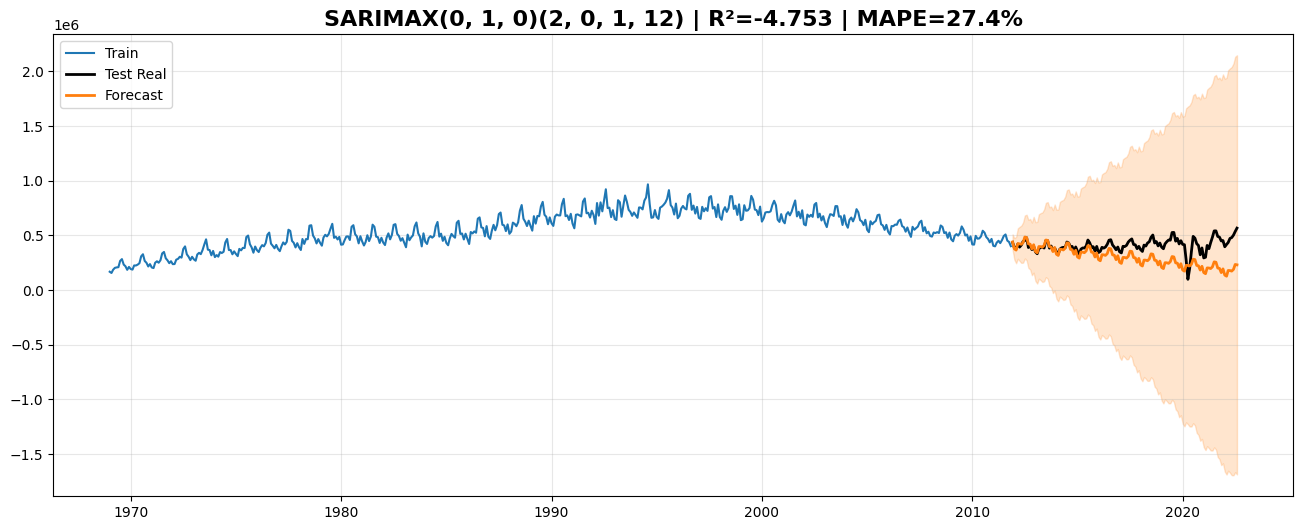

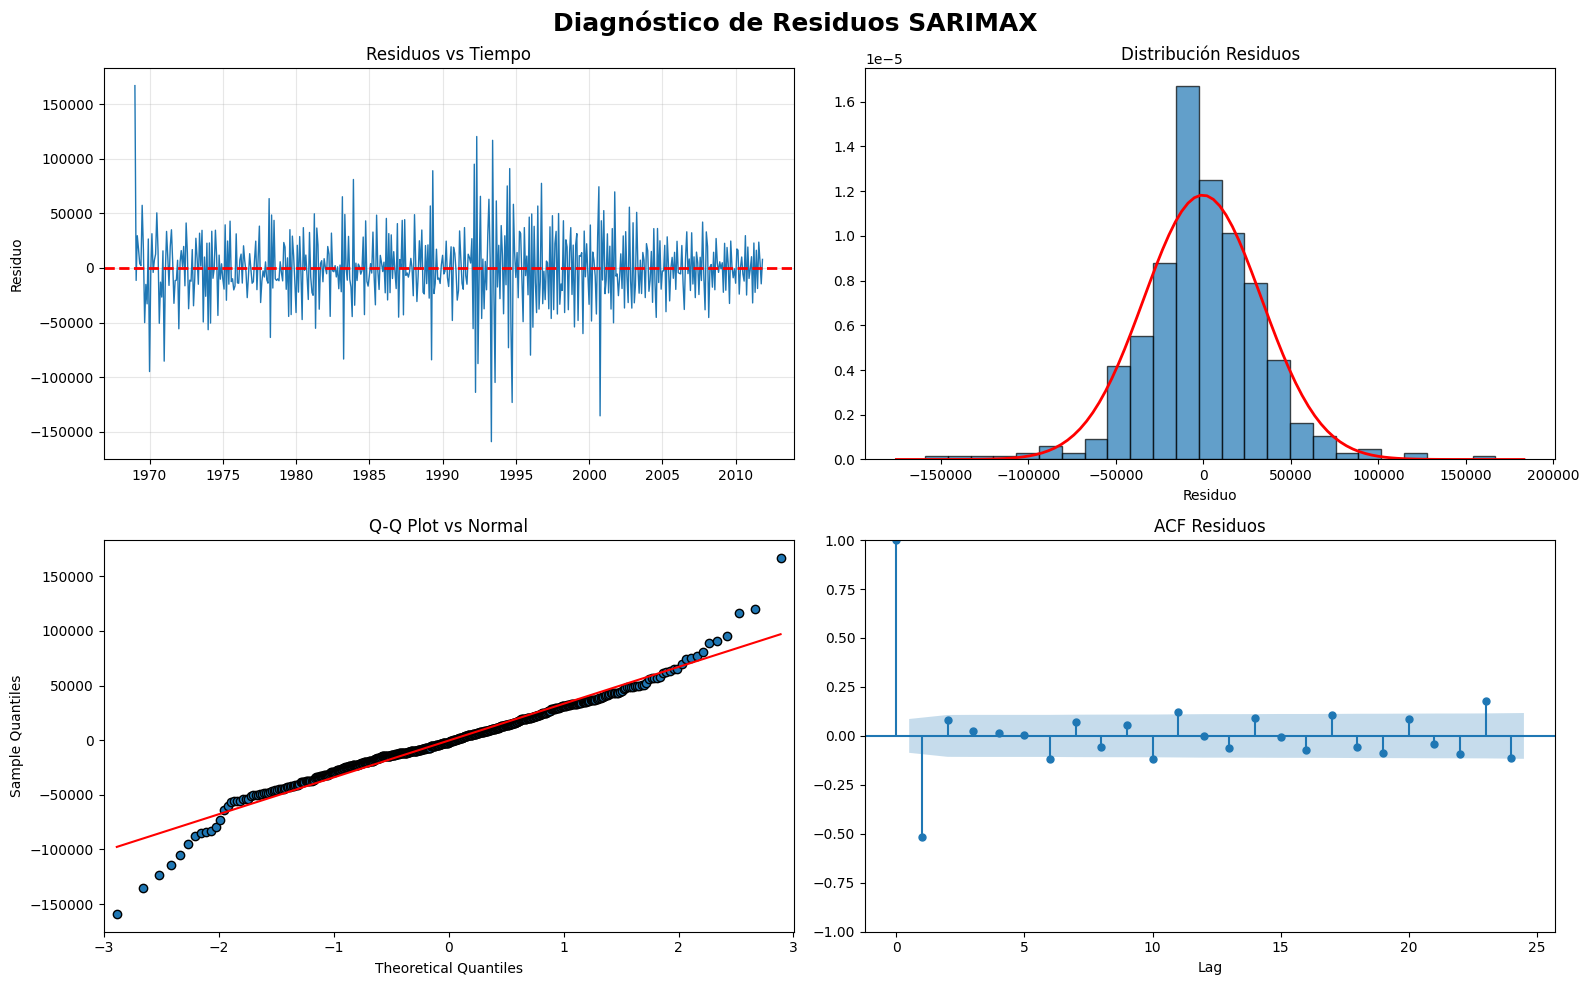

In [60]:
# ==================================
# 4. PLOT FORECAST
# ==================================
plt.figure(figsize=(16, 6))
plt.plot(train.index, train, label='Train', color='#1f77b4')
plt.plot(test.index, test, label='Test Real', color='black', lw=2)
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='#ff7f0e', lw=2)
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], 
                 color='#ff7f0e', alpha=0.2)
plt.legend()
plt.title(f'SARIMAX{order}{seasonal_order} | R²={r2:.3f} | MAPE={mape:.1f}%', 
          fontsize=16, weight='bold')
plt.grid(True, alpha=0.3)
plt.show()


# ==================================
# 5. DIAGNÓSTICO DE RESIDUOS
# ==================================
residuos = results.resid

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Diagnóstico de Residuos SARIMAX', fontsize=18, weight='bold')

# 5.1 Residuos vs Tiempo - Busca patrones
axes[0, 0].plot(residuos.index, residuos, color='#1f77b4', lw=1)
axes[0, 0].axhline(0, color='red', ls='--', lw=2)
axes[0, 0].set_title('Residuos vs Tiempo')
axes[0, 0].set_ylabel('Residuo')
axes[0, 0].grid(True, alpha=0.3)
# Si ves patrón = modelo malo. Debe ser ruido blanco

# 5.2 Histograma + KDE - Busca normalidad
axes[0, 1].hist(residuos, bins=25, density=True, color='#1f77b4', alpha=0.7, edgecolor='black')
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, residuos.mean(), residuos.std())
axes[0, 1].plot(x, p, 'r', lw=2)
axes[0, 1].set_title('Distribución Residuos')
axes[0, 1].set_xlabel('Residuo')
# Si no es campana = modelo malo

# 5.3 Q-Q Plot - Test visual de normalidad
qqplot(residuos, line='s', ax=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('#1f77b4')
axes[1, 0].get_lines()[0].set_markeredgecolor('black')
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].set_title('Q-Q Plot vs Normal')
# Si puntos se salen de línea roja = no normal

# 5.4 ACF de residuos - Busca autocorrelación
plot_acf(residuos, lags=24, ax=axes[1, 1])
axes[1, 1].set_title('ACF Residuos')
axes[1, 1].set_xlabel('Lag')
# Si hay barras fuera de banda azul = autocorrelación = modelo malo

plt.tight_layout()
plt.show()

In [61]:
# ==================================
# 6. TESTS ESTADÍSTICOS DE RESIDUOS
# ==================================
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n=== TESTS DE RESIDUOS ===")
# 1. Ljung-Box: p>0.05 = no autocorrelación = bueno
lb_test = acorr_ljungbox(residuos, lags=[12], return_df=True)
print(f"Ljung-Box p-value: {lb_test['lb_pvalue'].iloc[0]:.4f}")
if lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("✅ Residuos son ruido blanco")
else:
    print("❌ Residuos tienen autocorrelación. Mejora el modelo")

# 2. Jarque-Bera: p>0.05 = normales = bueno
jb_test = stats.jarque_bera(residuos.dropna())
print(f"Jarque-Bera p-value: {jb_test[1]:.4f}")
if jb_test[1] > 0.05:
    print("✅ Residuos son normales")
else:
    print("❌ Residuos no son normales. Hay outliers")

# 3. Skew y Kurtosis
print(f"Skew: {stats.skew(residuos):.3f}") # Cerca de 0
print(f"Kurtosis: {stats.kurtosis(residuos):.3f}") # Cerca de 0


=== TESTS DE RESIDUOS ===
Ljung-Box p-value: 0.0000
❌ Residuos tienen autocorrelación. Mejora el modelo
Jarque-Bera p-value: 0.0000
❌ Residuos no son normales. Hay outliers
Skew: -0.075
Kurtosis: 3.032


In [62]:
if r2 > 0.7 and mape < 10 and lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("✅ Modelo bueno. Úsalo para forecast")
else:
    print("❌ Modelo malo. Prueba otros p,d,q,P,D,Q o agrega exógenas")

❌ Modelo malo. Prueba otros p,d,q,P,D,Q o agrega exógenas
